# 06 - Model Comparison: Random Forest vs. Logistic Regression

**Goal for today:** train a second, structurally different algorithm on the exact
same data and split as notebook 05, compare it fairly against our baseline, and look
at feature importance to see which features the model actually relies on.

**Why this matters for MLA-C01 (Domain 2 - ML Model Development):**
The exam expects you to know multiple algorithm families and, critically, that
*trying a more powerful-sounding algorithm doesn't guarantee a better result*.
Comparing models fairly - same data, same split, same metrics - is exactly how you're
expected to reason about algorithm selection, rather than assuming complexity wins.

## Step 0: Reload data and recreate the exact same split as notebook 05

**Why recreate the split instead of just loading new data?** For a fair comparison,
both models need to be trained on identical data and tested on an identical holdout
set. `random_state=42` with the same `test_size` and `stratify=y` guarantees this
produces the exact same split as notebook 05 - not just a similar one.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/telco_churn_processed.csv')

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5634, 30), (1409, 30))

## Step 1: Retrain the Logistic Regression baseline (for a fair side-by-side)

**Why retrain it here instead of just reusing notebook 05's numbers?** Keeping both
models in the same notebook, run back-to-back against the same in-memory data, removes
any chance of a subtle mismatch (different pandas version behavior, a missed step,
etc.) silently making the comparison unfair. This costs almost nothing to re-run and
buys real confidence in the comparison.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

lr_pred = logreg.predict(X_test_scaled)
lr_proba = logreg.predict_proba(X_test_scaled)[:, 1]

## Step 2: Train a Random Forest

**What a Random Forest actually is:** instead of finding one weighted formula across
all features (like Logistic Regression does), a Random Forest builds many individual
**decision trees** - each one trained on a random subset of the data and features -
and then has them "vote." The final prediction is the average (for probabilities) or
majority (for hard predictions) across all trees. This ensemble approach often
captures more complex, non-linear patterns in data than a single linear model can.

**`n_estimators=200`** - the number of individual trees to build. More trees
generally means more stable predictions, at the cost of more compute time.

**Notice we do NOT scale the features for Random Forest.** Unlike Logistic
Regression, tree-based models split data by asking threshold questions like
"is tenure > 12?" - the actual scale of the numbers doesn't affect how those splits
work. Scaling is a Logistic-Regression-specific need, not a universal one - a good
example of why understanding *why* a step exists matters more than memorizing "always
scale before modeling."

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

## Step 3: Compare both models side-by-side

**What this cell does:** rather than printing each model's metrics separately (like
notebook 05 did), we build a small comparison table - one row per model, one column
per metric. This is a much better format for actually *comparing*, rather than
reading two blocks of numbers and mentally lining them up yourself.

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

def get_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_proba),
    'Random Forest': get_metrics(y_test, rf_pred, rf_proba),
}).T

results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
Random Forest,0.793471,0.639731,0.508021,0.566319,0.825688


**Read this table carefully - the result may surprise you.** It's tempting to assume
a more sophisticated-sounding algorithm automatically wins. Look at whether Random
Forest actually beats Logistic Regression across these metrics, or not.

If Random Forest comes out *behind* the simpler baseline here, that is a completely
normal, real result - and an important lesson in itself: **out-of-the-box performance
depends heavily on the algorithm's default settings (hyperparameters), and a more
flexible model isn't automatically better without tuning.** Random Forest has several
tunable knobs (tree depth, number of trees, minimum samples per split) that we haven't
touched - we used sensible defaults, not an optimized configuration. This is exactly
why Domain 2 covers hyperparameter tuning as its own topic, which we'll get to in a
later session.

## Step 4: Feature importance - what is the Random Forest actually using?

**What this cell does:** `rf.feature_importances_` is an array, one value per
feature, showing how much each feature contributed to the trees' decisions overall
(technically, how much each feature reduced impurity across all splits in the
forest - but the practical reading is simple: higher number = the model leaned on
this feature more).

We build a pandas Series pairing each importance score with its feature name, then
sort it so the most influential features appear first.

In [6]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

TotalCharges                      0.192272
tenure                            0.170189
MonthlyCharges                    0.168340
PaymentMethod_Electronic check    0.038161
InternetService_Fiber optic       0.037199
Contract_Two year                 0.031165
gender_Male                       0.028661
OnlineSecurity_Yes                0.028363
PaperlessBilling_Yes              0.025466
Partner_Yes                       0.023238
dtype: float64

**Compare this list against what we found visually back in notebook 03.** We
discovered by eye that `Contract` type had a huge effect on churn rate (42.7%
Month-to-month vs. 2.8% Two-year). Check whether `Contract`-related features show up
near the top of this importance list - if they do, that's a genuinely satisfying
result: it means the model's own internal reasoning lines up with the pattern you
already spotted by hand through EDA. That agreement between exploratory analysis and
model behavior is exactly what you want to see - it builds real trust in the model,
rather than treating it as an unexplainable black box.

## Step 5: Plot it

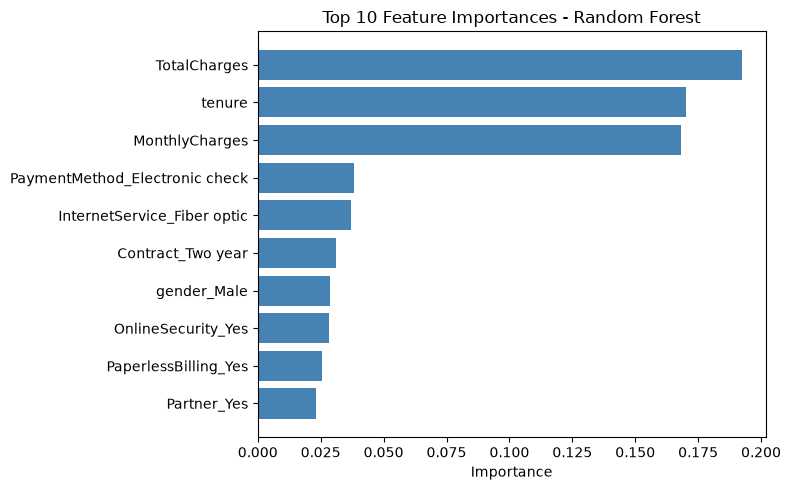

In [7]:
import matplotlib.pyplot as plt

top_10 = importances.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_10.index[::-1], top_10.values[::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

`[::-1]` reverses the order for both the labels and values - without it, the most
important feature would plot at the bottom of the chart instead of the top, since
`barh` draws from the bottom up by default.

---

**That's it for today.** Small, complete increment:
- retrained Logistic Regression and trained a new Random Forest on the identical
  train/test split, for a fair comparison
- built a side-by-side metrics table rather than comparing numbers by eye
- learned that a more complex model doesn't automatically outperform a simpler one
  without tuning
- extracted and visualized feature importance, and connected it back to what we
  discovered visually in notebook 03

**Next session:** hyperparameter tuning - we'll try to actually improve the Random
Forest's out-of-the-box performance by systematically searching over its key settings,
rather than guessing.